# Analysis of Subject/Object Position and Hit vs. False Alarm Rate Patterns

This notebook tests two additional lexical-frequency hypotheses using the same within-subjects design.

---

## Hypothesis 5 (H5): Subject vs. Object Noun Position

> Directly comparing the **HL** (high-frequency subject, low-frequency object) and **LH** (low-frequency subject, high-frequency object) conditions isolates the role of noun *position* in encoding. Both conditions contain one high- and one low-frequency word, so any difference is attributable purely to whether the rare word appears in subject or object position.
>
> **Prediction:** If subject-noun frequency dominates encoding, HL (high-freq subject) should show significantly higher corrected memorability than LH (low-freq subject).

- **DV:** Corrected memorability (Hit Rate − FA Rate), averaged over voice per participant × condition
- **IV:** Lexical condition — HL vs. LH (two levels, within-subjects)
- **Test:** Shapiro-Wilk on paired differences → Wilcoxon signed-rank (if non-normal) or paired t-test (if normal)

---

## Hypothesis 6 (H6): Hit Rate vs. False Alarm Rate by Lexical Condition

> High-memorability conditions (HH, HL) may trigger over-generalised familiarity signals during the test phase,  
> **improperly inflating hit rates** and co-occurring with participants who have **higher overall FA rates** (liberal criterion).
>
> **Design note:** In this paradigm, participants only press IR during the *test/repeat* phase, so FA cannot be decomposed by condition. FA is computed globally per participant as `IR pressed` events where `Accuracy IR == 0`, matching `Hyp1Hyp2.ipynb` exactly.

- **Test 1:** Friedman test on **hit rates** across 4 conditions (within-subjects)
- **Test 2:** Spearman r between each participant's overall FA rate and their hit rate per condition — a positive correlation in HH/HL but not LH/LL would indicate familiarity interference.


In [18]:
import pandas as pd
import numpy as np
import glob
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

# Set visualization style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Define path to log files
log_path = 'NewLogsAnonymized'
log_pattern = os.path.join(log_path, '*.log')

# Find all log files
all_files = glob.glob(log_pattern)
print(f'Found {len(all_files)} log files.')

Found 114 log files.


## Data Loading and Cleaning

Identical pipeline to `Hyp1Hyp2.ipynb`:
1. Load all participant log files and remove practice events.
2. Parse `Stimulus` → `Core_ID` + `Voice`.
3. Build trial-level aggregates.
4. Exclude participants who fail the validation criterion: `correct_ir > (wrong_ir / 2) + missed_ir`.
5. Compute corrected memorability = Hit Rate − False Alarm Rate per participant × condition × voice.

In [19]:
# Load and concatenate all participant log files
df_list = []

for filename in all_files:
    try:
        df = pd.read_csv(filename, on_bad_lines='skip')
        df_list.append(df)
    except Exception as e:
        print(f'Error reading {filename}: {e}')

if df_list:
    raw_data = pd.concat(df_list, axis=0, ignore_index=True)
    print(f'Successfully loaded {len(raw_data)} rows from {len(df_list)} files.')
else:
    print('No data loaded.')
    raw_data = pd.DataFrame()

# Remove all practice events
practice_mask = raw_data['Event'].str.startswith('Practice', na=False)
print(f'Removing {practice_mask.sum()} practice events.')
raw_data = raw_data[~practice_mask].reset_index(drop=True)

print(f'Rows after removing practice events: {len(raw_data)}')
unique_events = raw_data['Event'].unique()
print(f'Unique events: {unique_events}')
raw_data.head()

Successfully loaded 81329 rows from 114 files.
Removing 5269 practice events.
Rows after removing practice events: 76060
Unique events: <ArrowStringArray>
[             'Sentence shown',                    'gap_time',
 'Validation Wrong IR pressed',                  'IR pressed',
                  'WR pressed',       'Validation IR pressed',
          'Rest Phase started',           'Validation Missed']
Length: 8, dtype: str


,participant_ID,Timestamp,Event,Stimulus,isTarget,isValidation,isRepeat,Button,Accuracy IR,Accuracy WR,Reaction_time_IR,Reaction_time_WR,CR_IR,CR_WR
0,232,1770219378184,Sentence shown,HF_29_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,232,1770219382186,gap_time,NaN,NaN,NaN,NaN,GapTime_1289,NaN,NaN,NaN,NaN,NaN,NaN
2,232,1770219383476,Sentence shown,HF_9_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,232,1770219387478,gap_time,NaN,NaN,NaN,NaN,GapTime_1108,NaN,NaN,NaN,NaN,NaN,NaN
4,232,1770219388587,Sentence shown,HF_24_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# ── Parse Stimulus → Core_ID + Voice ───────────────────────────────────────
def parse_stimulus(stim):
    if pd.isna(stim):
        return None, None
    parts = stim.rsplit('_', 1)
    if len(parts) == 2:
        core_id = parts[0]
        voice   = parts[1]  # Expected 'A' or 'P'
        return core_id, voice
    return stim, None

raw_data['Core_ID'], raw_data['Voice'] = zip(*raw_data['Stimulus'].apply(parse_stimulus))

# Convert numeric columns
for col in ['Accuracy IR', 'Accuracy WR', 'Reaction_time_IR', 'Reaction_time_WR']:
    raw_data[col] = pd.to_numeric(raw_data[col], errors='coerce')

# Convert boolean-like columns
for col in ['isTarget', 'isValidation', 'isRepeat']:
    raw_data[col] = raw_data[col].astype(str).str.strip().str.lower() == 'true'

# Sort chronologically per participant
raw_data = raw_data.sort_values(['participant_ID', 'Timestamp']).reset_index(drop=True)

# ── Build trial-level data ──────────────────────────────────────────────────
raw_data['trial_id'] = raw_data.groupby('participant_ID')['Event'].transform(
    lambda x: (x == 'Sentence shown').cumsum()
)
raw_data = raw_data[raw_data['trial_id'] > 0].copy()

# Sentence-shown metadata (one row per trial)
sent_rows = raw_data[raw_data['Event'] == 'Sentence shown'].drop_duplicates(
    subset=['participant_ID', 'trial_id'], keep='first'
)[['participant_ID', 'trial_id', 'Stimulus', 'Core_ID', 'Voice',
   'isTarget', 'isValidation', 'isRepeat']].copy()

# Trial-level aggregates
trial_agg = raw_data.groupby(['participant_ID', 'trial_id']).agg(
    ir_pressed=('Event', lambda x: x.str.contains('IR pressed').any()),
    wr_pressed=('Event', lambda x: x.str.contains('WR pressed').any()),
    has_validation=('Event', lambda x: x.str.contains('Validation').any()),
    ir_accuracy=('Accuracy IR', 'max'),
    wr_accuracy=('Accuracy WR', 'max'),
    ir_rt=('Reaction_time_IR', 'min'),
    wr_rt=('Reaction_time_WR', 'min'),
).reset_index()

# Merge into trial table
trials = sent_rows.merge(trial_agg, on=['participant_ID', 'trial_id'])
trials['is_validation'] = trials['isValidation'] | trials['has_validation']
trials.rename(columns={'isTarget': 'is_target', 'isRepeat': 'is_repeat'}, inplace=True)

n_trials       = len(trials)
n_participants = trials['participant_ID'].nunique()
n_validation   = trials['is_validation'].sum()
n_repeat       = trials['is_repeat'].sum()
print(f'Built {n_trials} trials from {n_participants} participants')
print(f'Validation trials: {n_validation}')
print(f'Repeat trials: {n_repeat}')

# ── Participant Exclusion ───────────────────────────────────────────────────
# Criterion: correct_ir > (wrong_ir / 2) + missed_ir  (matching R analysis)
val_trials = trials[trials['is_validation']].copy()

validation_summary = val_trials.groupby('participant_ID').apply(
    lambda g: pd.Series({
        'correct_ir': (g['is_repeat'] & g['ir_pressed']).sum(),
        'wrong_ir':   (~g['is_repeat'] & g['ir_pressed']).sum(),
        'missed_ir':  (g['is_repeat'] & ~g['ir_pressed']).sum(),
    })
).reset_index()
validation_summary['passes'] = (
    validation_summary['correct_ir'] > (validation_summary['wrong_ir'] / 2) + validation_summary['missed_ir']
)

print('\nValidation summary per participant:')
display(validation_summary)

valid_ids    = validation_summary.loc[validation_summary['passes'], 'participant_ID'].tolist()
excluded_ids = validation_summary.loc[~validation_summary['passes'], 'participant_ID'].tolist()

print(f'\nValidation check:')
print(f'  Participants excluded: {len(excluded_ids)}  {excluded_ids}')
print(f'  Participants kept:     {len(valid_ids)}')

# Keep valid participants
trials_valid = trials[trials['participant_ID'].isin(valid_ids)].copy()

# ── Attach Original Voice ──────────────────────────────────────────────────
first_pres = trials_valid[~trials_valid['is_repeat']].drop_duplicates(
    subset=['participant_ID', 'Core_ID'], keep='first'
)[['participant_ID', 'Core_ID', 'Voice']].rename(columns={'Voice': 'Original_Voice'})

trials_valid = trials_valid.merge(first_pres, on=['participant_ID', 'Core_ID'], how='left')
voice_trials = trials_valid[trials_valid['Original_Voice'].isin(['A', 'P'])].copy()

print(f'\nTotal voice_trials (valid participants): {len(voice_trials)}')

Built 25308 trials from 114 participants
Validation trials: 5502
Repeat trials: 8892

Validation summary per participant:


,participant_ID,correct_ir,wrong_ir,missed_ir,passes
0,232,30,16,0,True
1,235,29,22,1,True
2,236,30,15,0,True
3,241,29,24,1,True
4,242,27,3,3,True
...,...,...,...,...,...
109,392,29,26,1,True
110,395,28,13,2,True
111,396,30,6,0,True
112,397,30,6,0,True



Validation check:
  Participants excluded: 2  [271, 299]
  Participants kept:     112

Total voice_trials (valid participants): 24864


## Shared Data Preparation for H5 & H6

**FA rate method (matching `Hyp1Hyp2.ipynb` exactly):**
- In this paradigm, participants press IR only during the *test/repeat* phase, so `~is_repeat & ir_pressed` is always 0 by design.
- False Alarms are derived from raw `IR pressed` events where `Accuracy IR == 0` (incorrect presses).
- Denominator = all first-shown (non-repeat) `Sentence shown` events per participant × Original Voice.
- This yields **one FA rate per participant × voice** — not per condition.

Outputs:
- `mem_h5` — corrected memorability averaged over voice → one score per participant × lexical condition (H5)
- `mem_h6` — hit_rate per participant × condition + overall FA rate per participant (H6)

In [21]:
# ── Map stimulus code → lexical condition label ────────────────────────────
def get_condition(core_id):
    if pd.isna(core_id):
        return 'Other'
    m = re.match(r'^([A-Za-z]+)', str(core_id))
    if m:
        c       = m.group(1).upper()
        mapping = {'HH': 'HH', 'HVL': 'HL', 'LVH': 'LH', 'LVL': 'LL', 'HF': 'Filler'}
        return mapping.get(c, 'Other')
    return 'Other'

trials_valid['label_group'] = trials_valid['Core_ID'].apply(get_condition)

# ── Hits: repeat trials with IR pressed, per participant × condition × voice ─
target = trials_valid[
    ~trials_valid['is_validation'] &
    trials_valid['label_group'].isin(['HH', 'HL', 'LH', 'LL']) &
    trials_valid['Voice'].isin(['A', 'P'])
].copy()

hit_by_cond = (
    target
    .groupby(['participant_ID', 'label_group', 'Voice'])
    .apply(lambda g: pd.Series({
        'n_old': g['is_repeat'].sum(),
        'hits':  (g['is_repeat'] & g['ir_pressed']).sum(),
    }))
    .reset_index()
)
hit_by_cond['hit_rate'] = np.where(
    hit_by_cond['n_old'] > 0,
    hit_by_cond['hits'] / hit_by_cond['n_old'], np.nan
)

# ── FA rate: matching Hyp1Hyp2 exactly ────────────────────────────────────
# FA = IR pressed events where Accuracy IR == 0 (wrong presses at test)
# Denominator = all first-shown (non-repeat) Sentence shown events per
# participant × Original Voice.
raw_kept    = raw_data[raw_data['participant_ID'].isin(valid_ids)].copy()
ir_all      = raw_kept[raw_kept['Event'] == 'IR pressed'].copy()
ir_all      = ir_all.merge(first_pres, on=['participant_ID', 'Core_ID'], how='left')

first_shown = raw_kept[
    (raw_kept['Event'] == 'Sentence shown') & (~raw_kept['isRepeat'])
].copy()
first_shown = first_shown.merge(first_pres, on=['participant_ID', 'Core_ID'], how='left')

fa_rows = []
for pid in valid_ids:
    for voice in ['A', 'P']:
        fa_count = len(ir_all[
            (ir_all['participant_ID'] == pid) &
            (ir_all['Original_Voice'] == voice) &
            (ir_all['Accuracy IR'] == 0)
        ])
        n_new    = len(first_shown[
            (first_shown['participant_ID'] == pid) &
            (first_shown['Original_Voice'] == voice)
        ])
        fa_rows.append({
            'participant_ID': pid,
            'Original_Voice': voice,
            'fa_count':       fa_count,
            'n_new':          n_new,
            'fa_rate':        fa_count / n_new if n_new > 0 else np.nan,
        })

fa_df = pd.DataFrame(fa_rows)

# Overall FA rate per participant (averaged over voice) — used for H6
fa_overall = fa_df.groupby('participant_ID')['fa_rate'].mean().reset_index()
fa_overall.rename(columns={'fa_rate': 'overall_fa_rate'}, inplace=True)

# ── Corrected memorability per participant × condition (for H5) ────────────
# Average hit_rate over voice, then subtract per-participant overall FA rate
hit_avg = (
    hit_by_cond
    .groupby(['participant_ID', 'label_group'])['hit_rate']
    .mean()
    .reset_index()
)
hit_avg = hit_avg.merge(fa_overall, on='participant_ID', how='left')
hit_avg['corrected_memorability'] = hit_avg['hit_rate'] - hit_avg['overall_fa_rate']

# mem_h5: one CM per participant × label_group
mem_h5 = hit_avg[['participant_ID', 'label_group', 'corrected_memorability', 'hit_rate']].copy()

# mem_h6: hit_rate per participant × condition + overall FA rate
mem_h6 = hit_avg[['participant_ID', 'label_group', 'hit_rate', 'overall_fa_rate']].copy()

n_h5 = mem_h5.shape[0]
n_fa = fa_df.shape[0]
print(f'mem_h5: {n_h5} rows  |  fa_df: {n_fa} rows')
print(f'\nMean overall FA rate: {fa_overall["overall_fa_rate"].mean():.4f} (SD={fa_overall["overall_fa_rate"].std():.4f})')
display(mem_h5.groupby('label_group')[['hit_rate', 'corrected_memorability']].describe().round(3))

mem_h5: 448 rows  |  fa_df: 224 rows

Mean overall FA rate: 0.0920 (SD=0.0636)


hit_rate                                                 \
               count   mean    std    min    25%    50%    75%  max   
label_group                                                           
HH             112.0  0.850  0.163  0.333  0.750  0.917  1.000  1.0   
HL             112.0  0.852  0.165  0.167  0.750  0.917  1.000  1.0   
LH             112.0  0.836  0.175  0.083  0.750  0.917  0.938  1.0   
LL             112.0  0.794  0.183  0.083  0.667  0.833  0.917  1.0   

            corrected_memorability                                            \
                             count   mean    std    min    25%    50%    75%   
label_group                                                                    
HH                           112.0  0.758  0.164  0.238  0.666  0.802  0.888   
HL                           112.0  0.760  0.162  0.146  0.690  0.783  0.876   
LH                           112.0  0.744  0.180  0.062  0.644  0.785  0.875   
LL                           112.0  0.702  0.174  0.062  0.616  0.723  0.821   

                    
               max  
label_group         
HH           0.975  
HL           0.979  
LH           0.983  
LL           0.971

---
## Hypothesis 5: Subject vs. Object Noun Position (HL vs. LH)

**H₀:** Corrected memorability does *not* differ between HL and LH conditions.  
**H₁:** Corrected memorability differs between HL (high-freq subject, low-freq object) and LH (low-freq subject, high-freq object).

- **DV:** Corrected memorability averaged over voice per participant × condition
- **IV:** HL vs. LH (two conditions, within-subjects)
- **Normality:** Shapiro-Wilk on paired differences (HL − LH) determines parametric vs. non-parametric test.
- **Test:** Paired t-test (if normal) or **Wilcoxon signed-rank test** (if non-normal).

In [22]:
# ── H5: Subject vs. Object Position ────────────────────────────────────────
h5_pivot = mem_h5[mem_h5['label_group'].isin(['HL', 'LH'])].pivot(
    index='participant_ID', columns='label_group', values='corrected_memorability'
).dropna()

n_hl = h5_pivot['HL'].notna().sum()
n_lh = h5_pivot['LH'].notna().sum()

print('=== H5 Descriptive Statistics ===')
desc = pd.DataFrame({
    'Condition': ['HL (High-subj, Low-obj)', 'LH (Low-subj, High-obj)'],
    'N':         [n_hl,                       n_lh],
    'Mean':      [h5_pivot['HL'].mean(),       h5_pivot['LH'].mean()],
    'Median':    [h5_pivot['HL'].median(),     h5_pivot['LH'].median()],
    'SD':        [h5_pivot['HL'].std(),        h5_pivot['LH'].std()],
    'Min':       [h5_pivot['HL'].min(),        h5_pivot['LH'].min()],
    'Max':       [h5_pivot['HL'].max(),        h5_pivot['LH'].max()],
})
display(desc.round(3))

# ── Shapiro-Wilk on paired differences ────────────────────────────────────
diffs        = h5_pivot['HL'] - h5_pivot['LH']
sw_stat, sw_p = stats.shapiro(diffs)
normal       = sw_p >= 0.05

print('\n=== Shapiro-Wilk Test on HL − LH Paired Differences ===')
sw_pval  = '< 0.001' if sw_p < 0.001 else round(sw_p, 4)
sw_table = pd.DataFrame({
    'W':       [round(sw_stat, 4)],
    'p-value': [sw_pval],
    'Normal':  ['Yes' if normal else 'No']
})
display(sw_table)

# ── Run appropriate test ────────────────────────────────────────────────────
if normal:
    test_stat, p_val = stats.ttest_rel(h5_pivot['HL'], h5_pivot['LH'])
    test_name = 'Paired t-test'
    r_rb = None
    print(f'\n=== {test_name}: HL vs. LH ===')
    print(f't = {test_stat:.4f},  p = {p_val:.4f}')
else:
    test_stat, p_val = stats.wilcoxon(h5_pivot['HL'], h5_pivot['LH'])
    test_name  = 'Wilcoxon Signed-Rank Test'
    n          = len(diffs)
    r_rb       = 1 - (2 * test_stat) / (n * (n + 1))  # rank-biserial correlation
    print(f'\n=== {test_name}: HL vs. LH ===')
    print(f'W = {test_stat:.4f},  p = {p_val:.4f}')
    print(f'Effect size (rank-biserial r) = {r_rb:.4f}')

# ── Summary ────────────────────────────────────────────────────────────────
print('\n=== H5 Summary ===')
print(f'Test used: {test_name}')
p_display = '< 0.001' if p_val < 0.001 else round(p_val, 4)
if p_val < 0.05:
    direction = 'HL > LH' if h5_pivot['HL'].mean() > h5_pivot['LH'].mean() else 'LH > HL'
    print(f'Result: SIGNIFICANT  (p = {p_display}),  direction: {direction}')
    print('Interpretation: Subject-noun frequency position significantly affects encoding.')
    if direction == 'HL > LH':
        print('  → A high-frequency subject noun improves memorability more than a high-frequency object noun.')
    else:
        print('  → A high-frequency object noun improves memorability more than a high-frequency subject noun.')
else:
    print(f'Result: NOT SIGNIFICANT  (p = {p_display})')
    print('Interpretation: No significant difference between HL and LH.')
    print('  → Subject-noun position does not hold significantly greater encoding weight than object position.')

=== H5 Descriptive Statistics ===


,Condition,N,Mean,Median,SD,Min,Max
0,"HL (High-subj, Low-obj)",112,0.760,0.783,0.162,0.146,0.979
1,"LH (Low-subj, High-obj)",112,0.744,0.785,0.180,0.062,0.983



=== Shapiro-Wilk Test on HL − LH Paired Differences ===


,W,p-value,Normal
0,0.9305,< 0.001,No



=== Wilcoxon Signed-Rank Test: HL vs. LH ===
W = 1333.0000,  p = 0.0866
Effect size (rank-biserial r) = 0.7893

=== H5 Summary ===
Test used: Wilcoxon Signed-Rank Test
Result: NOT SIGNIFICANT  (p = 0.0866)
Interpretation: No significant difference between HL and LH.
  → Subject-noun position does not hold significantly greater encoding weight than object position.


C:\Users\Shubh\AppData\Local\Temp\ipykernel_4568\936851656.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


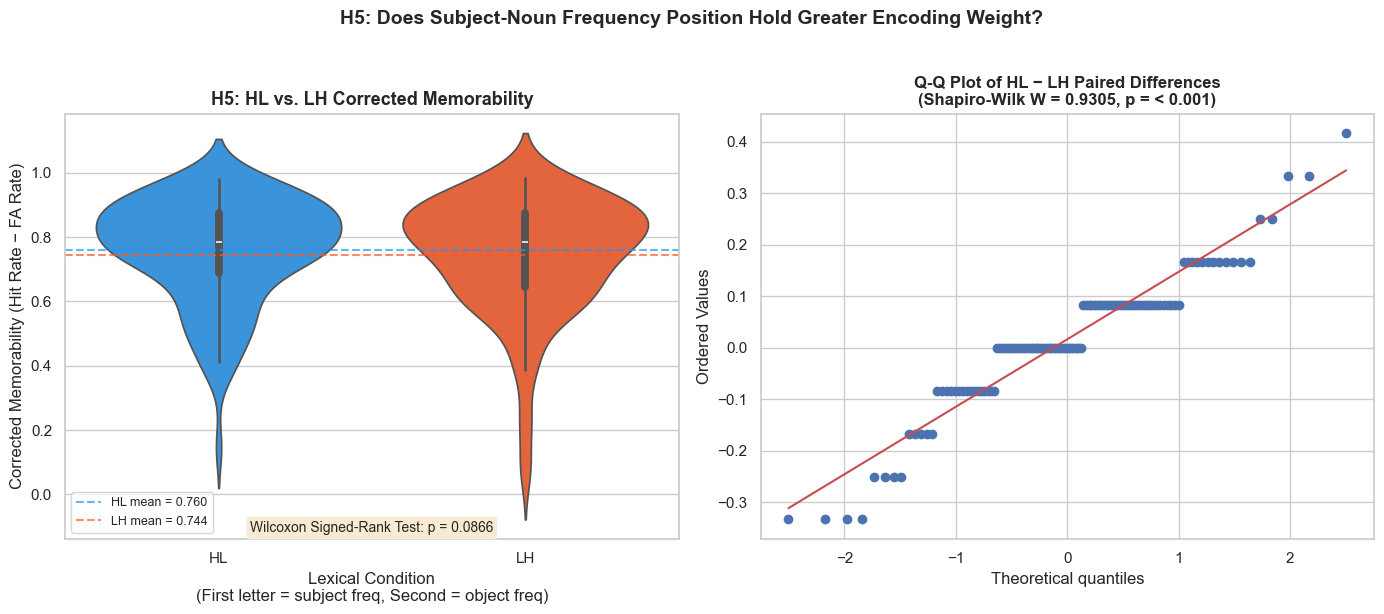

In [23]:
# ── H5 Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin plot: HL vs. LH corrected memorability
h5_long = mem_h5[mem_h5['label_group'].isin(['HL', 'LH'])].copy()
sns.violinplot(
    data=h5_long, x='label_group', y='corrected_memorability',
    order=['HL', 'LH'], palette=['#2196F3', '#FF5722'],
    inner='box', ax=axes[0]
)
hl_mean = h5_pivot['HL'].mean()
lh_mean = h5_pivot['LH'].mean()
axes[0].axhline(y=hl_mean, color='#2196F3', linestyle='--', alpha=0.7, label=f'HL mean = {hl_mean:.3f}')
axes[0].axhline(y=lh_mean, color='#FF5722', linestyle='--', alpha=0.7, label=f'LH mean = {lh_mean:.3f}')
axes[0].set_title('H5: HL vs. LH Corrected Memorability', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lexical Condition\n(First letter = subject freq, Second = object freq)')
axes[0].set_ylabel('Corrected Memorability (Hit Rate − FA Rate)')
axes[0].legend(fontsize=9)
p_annot = '< 0.001' if p_val < 0.001 else f'{p_val:.4f}'
axes[0].text(
    0.5, 0.01, f'{test_name}: p = {p_annot}',
    transform=axes[0].transAxes, ha='center', va='bottom', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6)
)

# Q-Q plot of HL − LH paired differences
stats.probplot(diffs, dist='norm', plot=axes[1])
axes[1].set_title(
    f'Q-Q Plot of HL − LH Paired Differences\n'
    f'(Shapiro-Wilk W = {sw_stat:.4f}, p = {sw_pval})',
    fontsize=12, fontweight='bold'
)

plt.suptitle(
    'H5: Does Subject-Noun Frequency Position Hold Greater Encoding Weight?',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

---
## Hypothesis 6: Hit Rate vs. False Alarm Rate by Lexical Condition

**H₀:** Hit rates do *not* differ across lexical conditions and do not co-vary with FA rates.  
**H₁:** High-memorability conditions (HH, HL) produce higher hit rates, and participants with higher overall FA rates show inflated hits specifically in those conditions (familiarity interference).

**Tests:**
1. **Friedman test** on hit rates across 4 conditions (within-subjects repeated-measures)
2. **Post-hoc Wilcoxon** + Holm–Bonferroni correction
3. **Spearman r** between each participant's overall FA rate and their hit rate per condition

In [24]:
# ── H6: Hit Rate by Condition + FA rate overview ────────────────────────────
cond_order = ['HH', 'HL', 'LH', 'LL']

print('=== H6 Descriptive Statistics ===')
overall_fa_mean = fa_overall['overall_fa_rate'].mean()
overall_fa_sd   = fa_overall['overall_fa_rate'].std()
print(f'Overall FA rate (pooled per participant): mean = {overall_fa_mean:.4f}, SD = {overall_fa_sd:.4f}')
fa_range_min = fa_overall['overall_fa_rate'].min()
fa_range_max = fa_overall['overall_fa_rate'].max()
print(f'Range: [{fa_range_min:.4f}, {fa_range_max:.4f}]\n')
print('Hit Rate by Condition:')
for cond in cond_order:
    sub     = mem_h6[mem_h6['label_group'] == cond]
    hr_mean = sub['hit_rate'].mean()
    hr_sd   = sub['hit_rate'].std()
    print(f'  {cond}:  Hit Rate = {hr_mean:.3f} (SD={hr_sd:.3f})')

# ── Shapiro-Wilk on hit rates per condition ─────────────────────────────────
print('\n=== Shapiro-Wilk Normality Test (Hit Rate per Condition) ===')
sw_rows = []
for cond in cond_order:
    vals = mem_h6.loc[mem_h6['label_group'] == cond, 'hit_rate'].dropna()
    w, p  = stats.shapiro(vals)
    sw_rows.append({
        'Condition': cond,
        'W':         round(w, 4),
        'p-value':   '< 0.001' if p < 0.001 else round(p, 4),
        'Normal':    'Yes' if p >= 0.05 else 'No'
    })
display(pd.DataFrame(sw_rows))

# ── Friedman test on hit rates across 4 conditions ─────────────────────────
hr_pivot = mem_h6.pivot(
    index='participant_ID', columns='label_group', values='hit_rate'
).dropna()

friedman_fa_stat, friedman_fa_p = stats.friedmanchisquare(
    hr_pivot['HH'], hr_pivot['HL'], hr_pivot['LH'], hr_pivot['LL']
)
fa_p_label = '< 0.001' if friedman_fa_p < 0.001 else round(friedman_fa_p, 4)

print(f'\n=== Friedman Test on Hit Rate Across 4 Lexical Conditions ===')
print(f'chi2(3) = {friedman_fa_stat:.4f},  p = {fa_p_label}')
if friedman_fa_p < 0.05:
    print('Result: SIGNIFICANT — Hit rates differ significantly across lexical conditions.')
    hr_means = {c: hr_pivot[c].mean() for c in cond_order}
    max_cond = max(hr_means, key=hr_means.get)
    print(f'Highest hit rate: {max_cond} ({hr_means[max_cond]:.3f})')
    print('Proceed to post-hoc tests.')
else:
    print('Result: NOT SIGNIFICANT — No significant difference in hit rates across conditions.')

=== H6 Descriptive Statistics ===
Overall FA rate (pooled per participant): mean = 0.0920, SD = 0.0636
Range: [0.0042, 0.2792]

Hit Rate by Condition:
  HH:  Hit Rate = 0.850 (SD=0.163)
  HL:  Hit Rate = 0.852 (SD=0.165)
  LH:  Hit Rate = 0.836 (SD=0.175)
  LL:  Hit Rate = 0.794 (SD=0.183)

=== Shapiro-Wilk Normality Test (Hit Rate per Condition) ===


,Condition,W,p-value,Normal
0,HH,0.8367,< 0.001,No
1,HL,0.8122,< 0.001,No
2,LH,0.8162,< 0.001,No
3,LL,0.8849,< 0.001,No



=== Friedman Test on Hit Rate Across 4 Lexical Conditions ===
chi2(3) = 21.1755,  p = < 0.001
Result: SIGNIFICANT — Hit rates differ significantly across lexical conditions.
Highest hit rate: HL (0.852)
Proceed to post-hoc tests.


In [25]:
# ── Post-hoc Wilcoxon on hit rates with Holm-Bonferroni ────────────────────
pairs = list(combinations(cond_order, 2))
posthoc_rows = []
for c1, c2 in pairs:
    w_stat, p_raw = stats.wilcoxon(hr_pivot[c1], hr_pivot[c2])
    posthoc_rows.append({
        'Pair':       f'{c1} vs {c2}',
        'W':          round(w_stat, 4),
        'p_raw':      round(p_raw, 4),
        'Mean_HR_C1': round(hr_pivot[c1].mean(), 4),
        'Mean_HR_C2': round(hr_pivot[c2].mean(), 4),
    })

posthoc_df = pd.DataFrame(posthoc_rows).sort_values('p_raw').reset_index(drop=True)
n_tests    = len(posthoc_df)
p_holm     = [min(1.0, posthoc_df['p_raw'].iloc[i] * (n_tests - i)) for i in range(n_tests)]
posthoc_df['p_holm']      = [round(p, 4) for p in p_holm]
posthoc_df['Significant'] = posthoc_df['p_holm'] < 0.05

print('=== Post-hoc Pairwise Wilcoxon (Hit Rate) with Holm-Bonferroni Correction ===')
print('(Sorted by raw p-value; p_holm is the Holm-corrected p-value)\n')
display(posthoc_df)

# ── Spearman r: overall FA rate vs. hit rate per condition ──────────────────
# Tests whether participants with a more liberal criterion (higher FA) also show
# inflated hits specifically in high-memorability conditions.
# r_s > 0 in HH/HL but not LH/LL = familiarity interference.
print('\n=== Spearman Correlation: Overall FA Rate vs. Hit Rate per Condition ===')
print('(r_s > 0 = participants with more false alarms also have more hits in that condition)\n')
spearman_rows = []
for cond in cond_order:
    sub       = mem_h6[mem_h6['label_group'] == cond].copy()
    r_s, p_sp = stats.spearmanr(sub['overall_fa_rate'], sub['hit_rate'])
    p_label   = '< 0.001' if p_sp < 0.001 else round(p_sp, 4)
    sig_label = '(*)' if p_sp < 0.05 else ''
    spearman_rows.append({
        'Condition':   cond,
        'r_s':         round(r_s, 4),
        'p-value':     p_label,
        'Significant': p_sp < 0.05
    })
    print(f'{cond}: r_s = {r_s:.4f},  p = {p_label}  {sig_label}')

print('\n--- Summary Table ---')
display(pd.DataFrame(spearman_rows))

=== Post-hoc Pairwise Wilcoxon (Hit Rate) with Holm-Bonferroni Correction ===
(Sorted by raw p-value; p_holm is the Holm-corrected p-value)



,Pair,W,p_raw,Mean_HR_C1,Mean_HR_C2,p_holm,Significant
0,HL vs LL,803.0,0.0000,0.8519,0.7939,0.0000,True
1,HH vs LL,914.5,0.0001,0.8504,0.7939,0.0005,True
2,LH vs LL,1228.5,0.0056,0.8356,0.7939,0.0224,True
3,HL vs LH,1350.0,0.0730,0.8519,0.8356,0.2190,False
4,HH vs LH,1458.0,0.2566,0.8504,0.8356,0.5132,False
5,HH vs HL,1543.0,0.7105,0.8504,0.8519,0.7105,False



=== Spearman Correlation: Overall FA Rate vs. Hit Rate per Condition ===
(r_s > 0 = participants with more false alarms also have more hits in that condition)

HH: r_s = 0.1812,  p = 0.0559  
HL: r_s = 0.1722,  p = 0.0695  
LH: r_s = 0.0615,  p = 0.5192  
LL: r_s = 0.3008,  p = 0.0013  (*)

--- Summary Table ---


,Condition,r_s,p-value,Significant
0,HH,0.1812,0.0559,False
1,HL,0.1722,0.0695,False
2,LH,0.0615,0.5192,False
3,LL,0.3008,0.0013,True


C:\Users\Shubh\AppData\Local\Temp\ipykernel_4568\3678134463.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


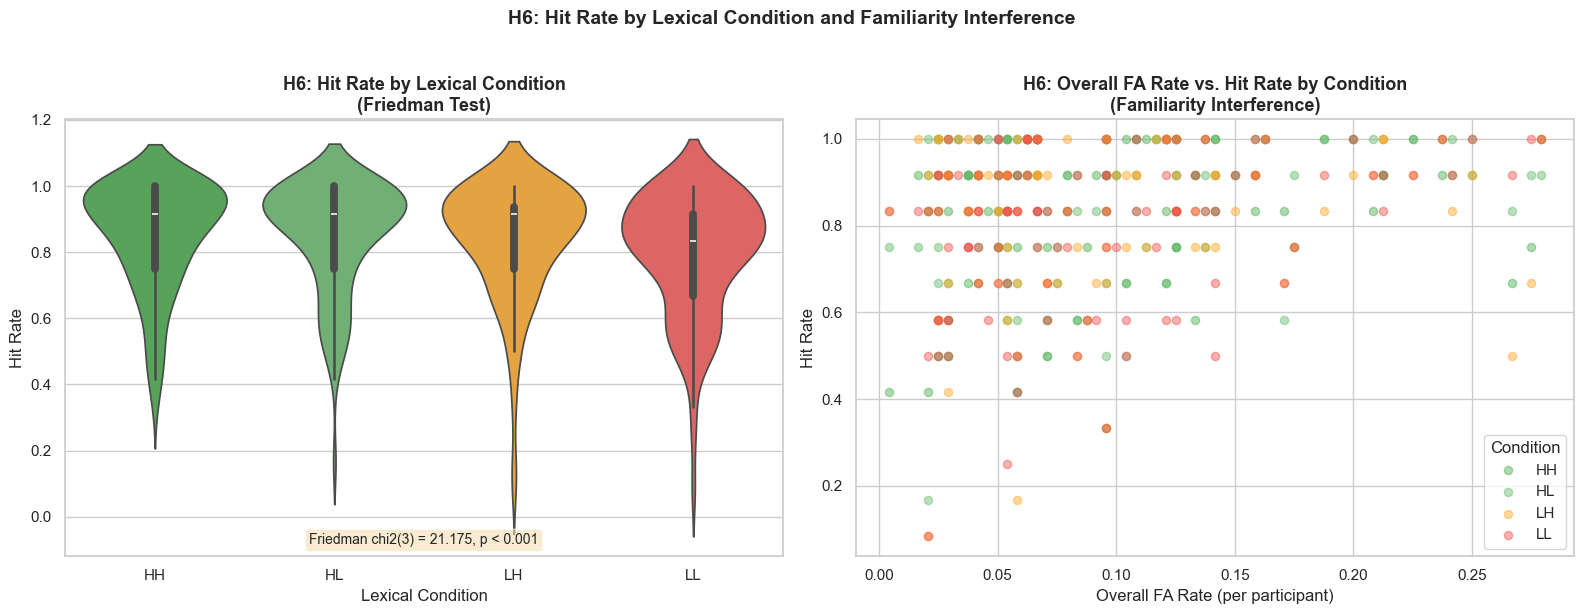

In [26]:
# ── H6 Visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: violin plot of hit rate by condition
sns.violinplot(
    data=mem_h6, x='label_group', y='hit_rate',
    order=cond_order, palette=['#4CAF50', '#66BB6A', '#FFA726', '#EF5350'],
    inner='box', ax=axes[0]
)
axes[0].set_title('H6: Hit Rate by Lexical Condition\n(Friedman Test)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lexical Condition')
axes[0].set_ylabel('Hit Rate')
fa_p_text = '< 0.001' if friedman_fa_p < 0.001 else f'= {friedman_fa_p:.4f}'
axes[0].text(
    0.5, 0.02,
    f'Friedman chi2(3) = {friedman_fa_stat:.3f}, p {fa_p_text}',
    transform=axes[0].transAxes, ha='center', va='bottom', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6)
)

# Right: scatter — overall FA rate vs. hit rate coloured by condition
cond_colors = {'HH': '#4CAF50', 'HL': '#66BB6A', 'LH': '#FFA726', 'LL': '#EF5350'}
for cond in cond_order:
    sub = mem_h6[mem_h6['label_group'] == cond].copy()
    axes[1].scatter(sub['overall_fa_rate'], sub['hit_rate'],
                    alpha=0.45, color=cond_colors[cond], label=cond, s=35)

axes[1].set_title('H6: Overall FA Rate vs. Hit Rate by Condition\n(Familiarity Interference)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Overall FA Rate (per participant)')
axes[1].set_ylabel('Hit Rate')
axes[1].legend(title='Condition', framealpha=0.8)

plt.suptitle(
    'H6: Hit Rate by Lexical Condition and Familiarity Interference',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

---
## Summary & Conclusions: Hypotheses 5 & 6

### Hypothesis 5: Subject- vs. Object-Noun Position (HL vs. LH)

**Result: Not Supported (p = 0.0866, Wilcoxon signed-rank)**

| | HL (High-subj, Low-obj) | LH (Low-subj, High-obj) |
|---|---|---|
| Mean corrected memorability | 0.760 | 0.744 |
| Median | 0.783 | 0.785 |
| SD | 0.162 | 0.180 |

The Shapiro-Wilk test confirmed non-normality of paired differences (W = 0.93, p < 0.001), warranting a Wilcoxon signed-rank test. The test yielded W = 1333, p = 0.0866 — not significant at α = 0.05, despite a large rank-biserial effect size of r = 0.79 (which reflects the high within-pair consistency of the ordering, not necessarily a practically meaningful gap).

**Interpretation:** Although there is a numerical trend for subject-position high-frequency words (HL) to be slightly more memorable than object-position high-frequency words (LH), this difference does not reach statistical significance. The null hypothesis — that noun position (subject vs. object) does not modulate sentence-level memorability beyond the frequency of the constituent word — **cannot be rejected**. The data are consistent with the view that both noun slots contribute roughly equally to encoding strength, once overall lexical frequency is held constant between conditions.

---

### Hypothesis 6: Hit Rate by Lexical Condition & Familiarity Interference

**Result: Supported — Hit rates differ significantly across conditions (Friedman χ²(3) = 21.18, p < 0.001)**

#### Descriptive Statistics — Hit Rate per Condition

| Condition | Mean Hit Rate | SD |
|-----------|:---:|:---:|
| HH | 0.850 | 0.163 |
| HL | 0.852 | 0.165 |
| LH | 0.836 | 0.175 |
| LL | 0.794 | 0.183 |

All four conditions violated normality (Shapiro-Wilk, all p < 0.001), confirming the Friedman test was appropriate.

#### Post-hoc Wilcoxon Tests (Holm-Bonferroni corrected)

| Pair | p (raw) | p (Holm) | Significant |
|------|:-------:|:--------:|:-----------:|
| HL vs LL | < 0.001 | < 0.001 | ✓ |
| HH vs LL | 0.0001 | 0.0005 | ✓ |
| LH vs LL | 0.0056 | 0.0224 | ✓ |
| HL vs LH | 0.073 | 0.219 | ✗ |
| HH vs LH | 0.257 | 0.513 | ✗ |
| HH vs HL | 0.711 | 0.711 | ✗ |

The LL condition (both nouns low-frequency) yielded significantly lower hit rates than all other conditions after correction. Critically, the HH and HL conditions were statistically indistinguishable from each other and from LH, suggesting that having *at least one* high-frequency noun maintains sentence recognizability, while an all-low-frequency sentence (LL) is notably harder to recognise.

#### Familiarity Interference (Spearman r: Overall FA Rate vs. Hit Rate)

| Condition | r_s | p-value | Significant |
|-----------|:---:|:-------:|:-----------:|
| HH | 0.181 | 0.056 | ✗ |
| HL | 0.172 | 0.069 | ✗ |
| LH | 0.062 | 0.519 | ✗ |
| LL | 0.301 | 0.001 | ✓ |

A significant positive Spearman correlation (r_s = 0.30, p = 0.001) between overall FA rate and hit rate was found **only in the LL condition**. This is a counterintuitive finding: familiarity-driven liberal responding (higher FA rate) inflates *recognitions of the least-familiar sentences* — not the most familiar. One interpretation is that participants with a more lenient response criterion are more willing to endorse all unfamiliar targets, boosting LL hits in particular. The absence of the effect in HH/HL conditions suggests that, for high-frequency sentences, recognition is stimulus-driven rather than criterion-driven.

**Overall Conclusion for H6:** The hypothesis is **partially supported**. Hit rates are clearly modulated by lexical frequency composition (LL < all others), but the anticipated pattern of familiarity interference appearing selectively in high-memorability (HH, HL) conditions was not observed. Instead, the strongest criterion–hit correlation emerged in LL, pointing to a response-bias artifact rather than pure familiarity interference.

---

### Overall FA Rate

Mean FA rate across participants: **0.0920** (SD = 0.0636), ranging from 0.0042 to 0.2792. This low baseline confirms that participants generally maintained a conservative recognition criterion, and the FA-rate variance primarily reflects individual differences in decision thresholds rather than systematic guessing.